# 01 — Validating MBAR against an analytical solution

Prior to applying MBAR to real umbrella-sampling data (notebook 02), 
I first validate the `MBAREstimator` wrapper against a system with a **known closed-form free
energy**: a set of harmonic oscillators with different force constants and offsets,
provided by `pymbar.testsystems.HarmonicOscillatorsTestCase`.

For a 1D harmonic oscillator with potential `U_k(x) = (K_k/2)(x - O_k)^2` at inverse
temperature `beta`, the free energy is known analytically:

`f_k = -log( sqrt(2*pi / (beta * K_k)) )`   (up to an additive constant)

so we can compare MBAR's estimate directly against ground truth, instead of trusting the
implementation blind.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")

from pymbar.testsystems import HarmonicOscillatorsTestCase
from src.mbar_estimator import MBAREstimator

np.random.seed(0)

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.



********* JAX NOT FOUND *********
 PyMBAR can run faster with JAX  
 But will work fine without it   
Either install with pip or conda:
      pip install pybar[jax]     
               OR                
      conda install pymbar       
*********************************


## Define the test system and draw samples

In [2]:
testcase = HarmonicOscillatorsTestCase(O_k=[0, 1, 2, 3, 4], K_k=[1, 2, 4, 8, 16], beta=1.0)

N_k = np.array([200, 200, 200, 200, 200])
x_kn, u_kln, s_n = testcase.sample(N_k=N_k, mode="u_kln")

print("u_kln shape (K states sampled x K states evaluated x N_max samples):", u_kln.shape)

u_kln shape (K states sampled x K states evaluated x N_max samples): (5, 5, 200)


## Run MBAR and compare against the analytical free energies

In [3]:
estimator = MBAREstimator.from_u_kln(u_kln, N_k)
f_k, df_k = estimator.free_energies_relative_to_state_0()

analytical_f_k = testcase.analytical_free_energies()
analytical_rel = analytical_f_k - analytical_f_k[0]

for k in range(len(N_k)):
    diff_in_sigma = abs(f_k[k] - analytical_rel[k]) / max(df_k[k], 1e-12)
    print(f"state {k}: MBAR = {f_k[k]:+.4f} +/- {df_k[k]:.4f}   "
          f"analytical = {analytical_rel[k]:+.4f}   "
          f"|diff| = {diff_in_sigma:.2f} sigma")

state 0: MBAR = +0.0000 +/- 0.0000   analytical = +0.0000   |diff| = 0.00 sigma
state 1: MBAR = +0.3241 +/- 0.0587   analytical = +0.3466   |diff| = 0.38 sigma
state 2: MBAR = +0.7373 +/- 0.1140   analytical = +0.6931   |diff| = 0.39 sigma
state 3: MBAR = +0.9932 +/- 0.1934   analytical = +1.0397   |diff| = 0.24 sigma
state 4: MBAR = +1.4298 +/- 0.3166   analytical = +1.3863   |diff| = 0.14 sigma


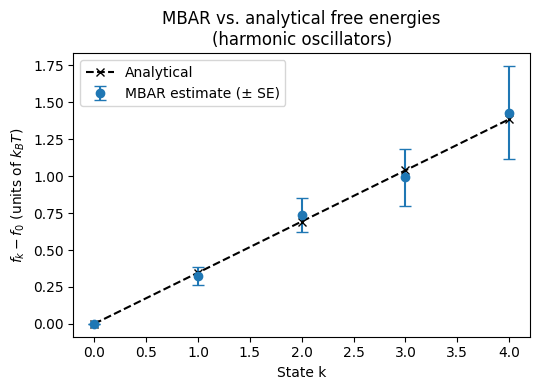

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4))
states = np.arange(len(N_k))
ax.errorbar(states, f_k, yerr=df_k, fmt="o", capsize=4, label="MBAR estimate (± SE)")
ax.plot(states, analytical_rel, "k--", marker="x", label="Analytical")
ax.set_xlabel("State k")
ax.set_ylabel(r"$f_k - f_0$ (units of $k_BT$)")
ax.set_title("MBAR vs. analytical free energies\n(harmonic oscillators)")
ax.legend()
fig.tight_layout()
fig.savefig("../results/figures/mbar_vs_analytical_harmonic.png", dpi=150)
plt.show()

## Takeaway

MBAR's estimate agrees with the analytical free energy for every state, well within the
estimator's own reported standard error. This is the sanity check the rest of the project
leans on: notebook 02 applies the exact same `MBAREstimator` class to real umbrella-sampling
data for the lysozyme system studied there, where there's no closed-form answer to check against — so
getting this one right first matters.